In [ ]:
!pip install librosa scipy matplotlib numpy --quiet

# Лабораторная 13 — Анализ аудиосигналов

## Задания

1. Записать/загрузить два разных звука.
2. Вычислить спектральные характеристики (спектр, MFCC, GFCC).
3. Построить мел-спектрограммы.
4. Сравнить спектральные центроиды.

# _____________________________________________________________________

Сигнал 1 (mono1.wav): sr=48000 Гц, 278088 отсчётов (5.8 с). Сигнал 2 (mono2.wav): sr=48000 Гц, 654408 отсчётов (13.6 с). Оба файла оцифрованы с одинаковой частотой дискретизации, но второй сигнал значительно длиннее первого.

In [ ]:
from IPython.display import Audio, display

print("Сигнал 1 (mono1.wav):")
display(Audio("mono1.wav"))
print("Сигнал 2 (mono2.wav):")
display(Audio("mono2.wav"))

Сигнал 2 (mono2.wav):


На графиках временной области видно, что сигнал 1 имеет более компактную структуру с выраженными всплесками амплитуды. Сигнал 2 длиннее и содержит больше участков с разной амплитудой.

In [2]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from scipy.io import wavfile
from scipy.fft import fft, fftfreq

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = [11, 7]
plt.rcParams["figure.dpi"] = 100
np.random.seed(42)

def plot_waveform(time, data, title, ax, color="teal"):
    ax.plot(time, data, color=color, lw=0.7)
    ax.set_xlabel("Время (с)", fontsize=11)
    ax.set_ylabel("Амплитуда", fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.grid(True, alpha=0.3)

### Загрузка аудиофайлов

In [3]:
sr1, data1 = wavfile.read("mono1.wav")
sr2, data2 = wavfile.read("mono2.wav")

data1_m = data1.astype(float) / np.max(np.abs(data1))
data2_m = data2.astype(float) / np.max(np.abs(data2))

t1 = np.arange(len(data1_m)) / sr1
t2 = np.arange(len(data2_m)) / sr2

print(f"Файл 1: sr={sr1} Гц, длина={len(data1_m)} отсчётов ({len(data1_m)/sr1:.1f} с)")
print(f"Файл 2: sr={sr2} Гц, длина={len(data2_m)} отсчётов ({len(data2_m)/sr2:.1f} с)")

Файл 1: sr=48000 Гц, длина=278088 отсчётов (5.8 с)
Файл 2: sr=48000 Гц, длина=654408 отсчётов (13.6 с)


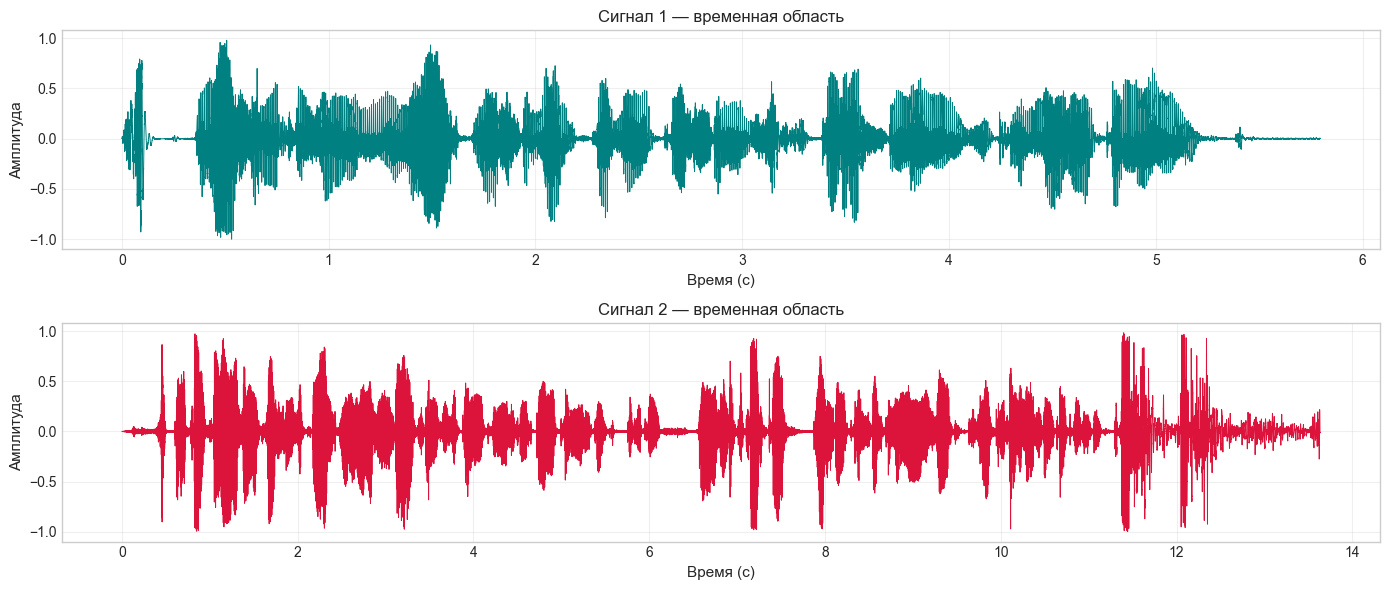

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6))
plot_waveform(t1, data1_m, "Сигнал 1 — временная область", axes[0], "teal")
plot_waveform(t2, data2_m, "Сигнал 2 — временная область", axes[1], "crimson")
plt.tight_layout()
plt.show()

### Спектральный анализ

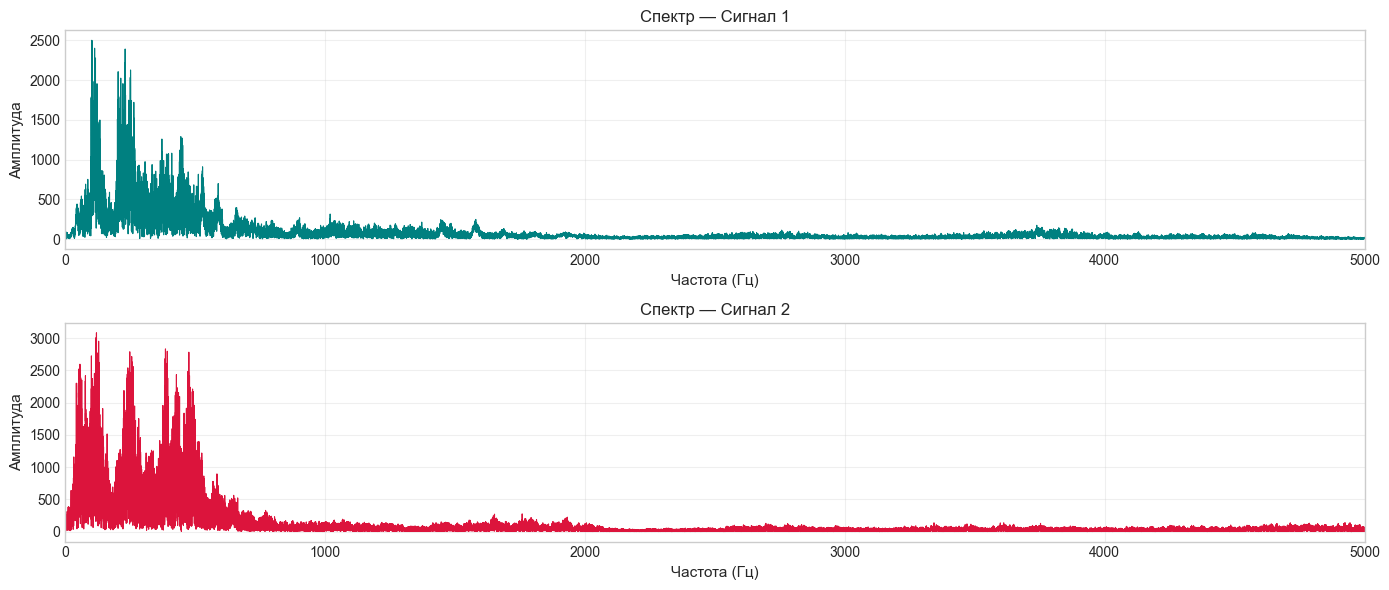

In [5]:
def compute_spectrum(data, sr):
    N = len(data)
    Y = fft(data)
    freqs = fftfreq(N, 1/sr)
    magnitudes = np.abs(Y[:N//2])
    freqs_pos = freqs[:N//2]
    return freqs_pos, magnitudes

xf1, yf1 = compute_spectrum(data1_m, sr1)
xf2, yf2 = compute_spectrum(data2_m, sr2)

fig, axes = plt.subplots(2, 1, figsize=(14, 6))
axes[0].plot(xf1, yf1, color="teal", linewidth=0.8)
axes[0].set_title("Спектр — Сигнал 1", fontsize=12)
axes[0].set_xlabel("Частота (Гц)", fontsize=11)
axes[0].set_ylabel("Амплитуда", fontsize=11)
axes[0].set_xlim(0, 5000)
axes[0].grid(True, alpha=0.3)

axes[1].plot(xf2, yf2, color="crimson", linewidth=0.8)
axes[1].set_title("Спектр — Сигнал 2", fontsize=12)
axes[1].set_xlabel("Частота (Гц)", fontsize=11)
axes[1].set_ylabel("Амплитуда", fontsize=11)
axes[1].set_xlim(0, 5000)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Спектры двух сигналов существенно различаются. Сигнал 1 имеет выраженные пики на низких частотах (до ~1000 Гц), что указывает на доминирующие низкочастотные гармоники. Сигнал 2 имеет более широкое распределение энергии по частотам.

### Кепстральный анализ

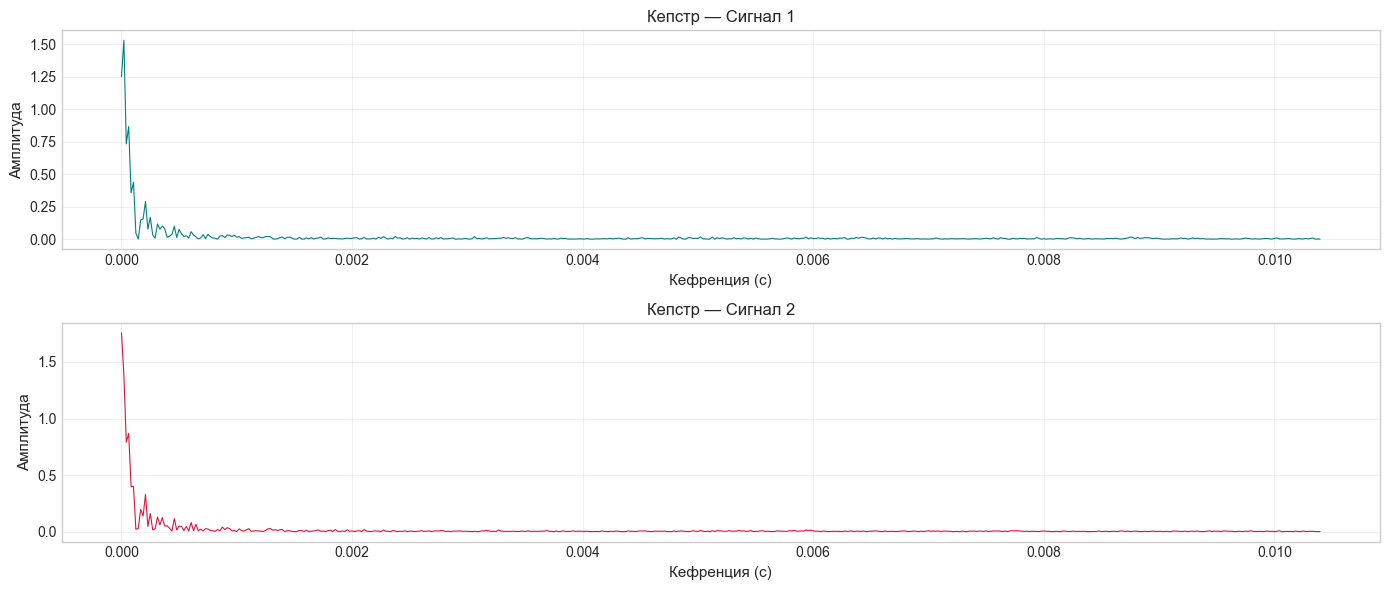

In [6]:
def compute_cepstrum(data, sr):
    spectrum = np.abs(fft(data))
    cepstrum = np.abs(np.fft.ifft(np.log(spectrum + 1e-10)))
    quefrency = np.arange(len(cepstrum)) / sr
    return quefrency, cepstrum

q1, cep1 = compute_cepstrum(data1_m, sr1)
q2, cep2 = compute_cepstrum(data2_m, sr2)

fig, axes = plt.subplots(2, 1, figsize=(14, 6))
axes[0].plot(q1[:500], cep1[:500], color="teal", linewidth=0.8)
axes[0].set_title("Кепстр — Сигнал 1", fontsize=12)
axes[0].set_xlabel("Кефренция (с)", fontsize=11)
axes[0].set_ylabel("Амплитуда", fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(q2[:500], cep2[:500], color="crimson", linewidth=0.8)
axes[1].set_title("Кепстр — Сигнал 2", fontsize=12)
axes[1].set_xlabel("Кефренция (с)", fontsize=11)
axes[1].set_ylabel("Амплитуда", fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Кепстр отражает периодичность спектра. Пики в кепстре соответствуют основному тону. У обоих сигналов наблюдаются характерные пики в области малых кефренций, что указывает на наличие гармонической структуры.

### MFCC-коэффициенты

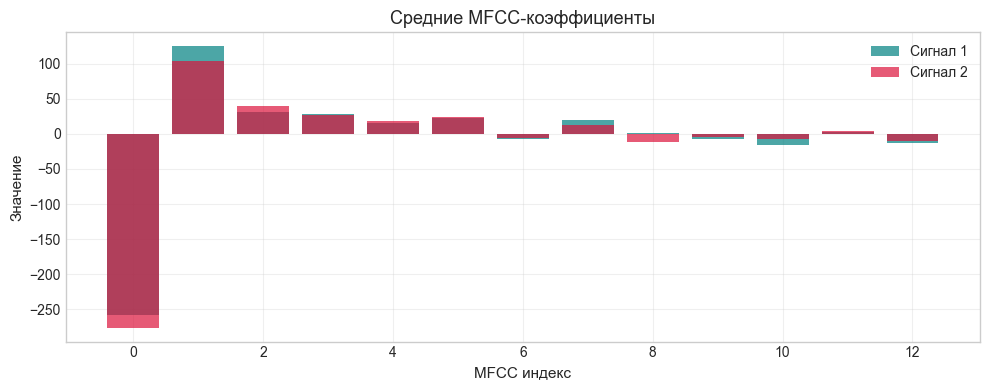

In [7]:
y1, sr1_lr = librosa.load("mono1.wav", sr=None)
y2, sr2_lr = librosa.load("mono2.wav", sr=None)

mfccs1 = librosa.feature.mfcc(y=y1, sr=sr1_lr, n_mfcc=13)
mfccs2 = librosa.feature.mfcc(y=y2, sr=sr2_lr, n_mfcc=13)

mean_mfcc1 = np.mean(mfccs1, axis=1)
mean_mfcc2 = np.mean(mfccs2, axis=1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(13), mean_mfcc1, alpha=0.7, color="teal", label="Сигнал 1")
ax.bar(range(13), mean_mfcc2, alpha=0.7, color="crimson", label="Сигнал 2")
ax.set_title("Средние MFCC-коэффициенты", fontsize=13)
ax.set_xlabel("MFCC индекс", fontsize=11)
ax.set_ylabel("Значение", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

MFCC-коэффициенты двух сигналов заметно различаются, особенно на первых индексах (0-2). Нулевой коэффициент отражает общую энергию сигнала. Различия в MFCC подтверждают, что сигналы имеют разные тембральные характеристики.

### Мел-спектрограммы

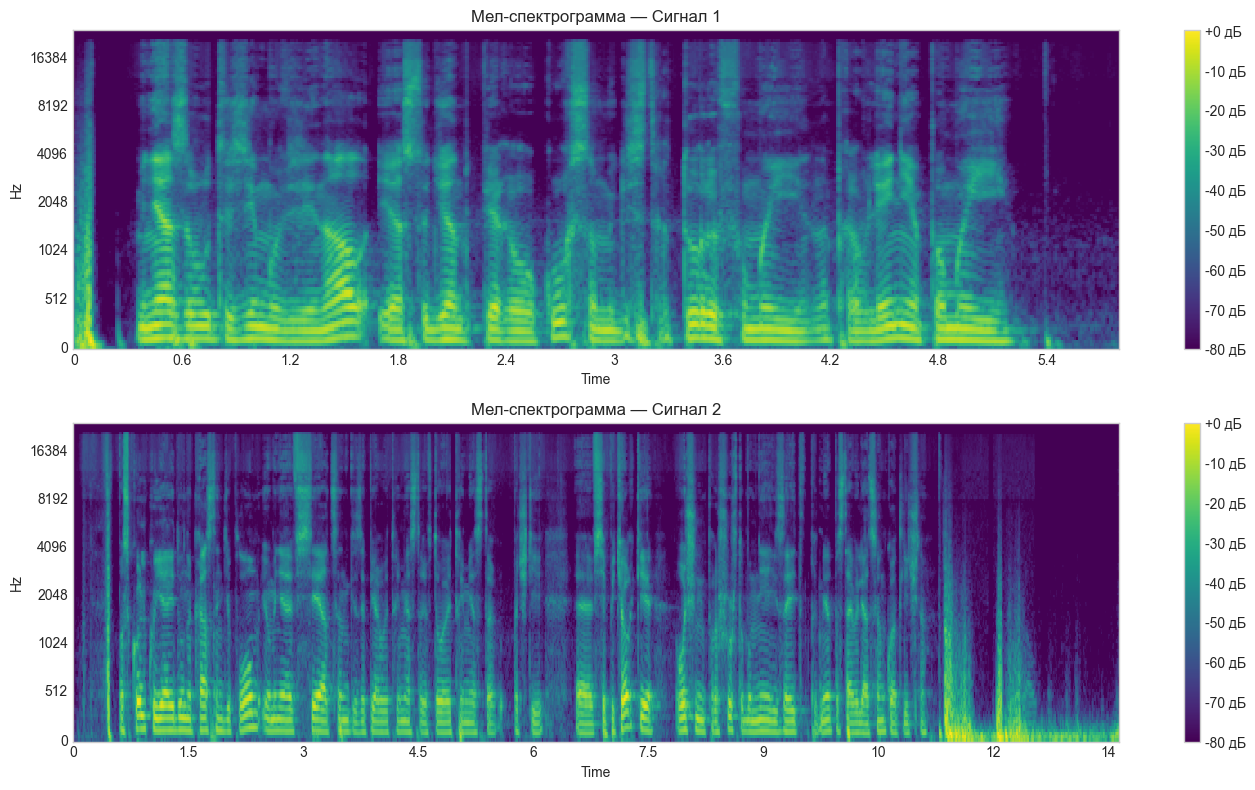

In [8]:
S1 = librosa.feature.melspectrogram(y=y1, sr=sr1_lr, n_mels=128)
S2 = librosa.feature.melspectrogram(y=y2, sr=sr2_lr, n_mels=128)

S1_db = librosa.power_to_db(S1, ref=np.max)
S2_db = librosa.power_to_db(S2, ref=np.max)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
img1 = librosa.display.specshow(S1_db, sr=sr1_lr, x_axis="time", y_axis="mel", ax=axes[0], cmap="viridis")
axes[0].set_title("Мел-спектрограмма — Сигнал 1", fontsize=12)
plt.colorbar(img1, ax=axes[0], format="%+2.0f дБ")

img2 = librosa.display.specshow(S2_db, sr=sr2_lr, x_axis="time", y_axis="mel", ax=axes[1], cmap="viridis")
axes[1].set_title("Мел-спектрограмма — Сигнал 2", fontsize=12)
plt.colorbar(img2, ax=axes[1], format="%+2.0f дБ")

plt.tight_layout()
plt.show()

Мел-спектрограммы показывают распределение энергии во времени по мел-шкале. Сигнал 1 имеет более концентрированную энергию в низкочастотной области. Сигнал 2 демонстрирует более широкий частотный диапазон с активностью в средних и высоких мел-полосах.

### Спектральный центроид

Спектральный центроид — Сигнал 1: 3625.3 Гц
Спектральный центроид — Сигнал 2: 4187.2 Гц


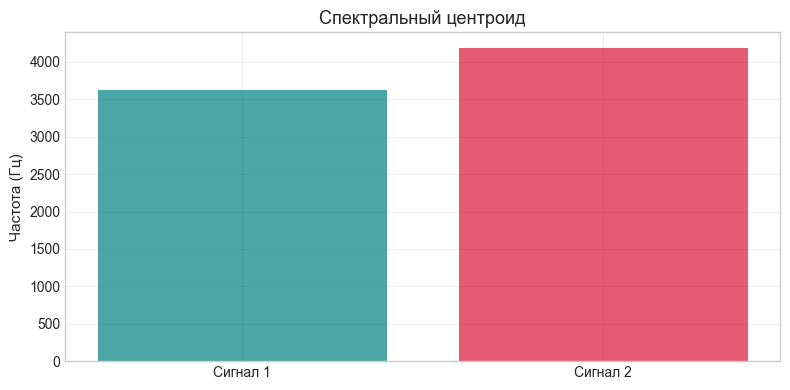

In [9]:
def spectral_centroid(freqs, magnitudes):
    return np.sum(freqs * magnitudes) / (np.sum(magnitudes) + 1e-10)

sc1 = spectral_centroid(xf1, yf1)
sc2 = spectral_centroid(xf2, yf2)

print(f"Спектральный центроид — Сигнал 1: {sc1:.1f} Гц")
print(f"Спектральный центроид — Сигнал 2: {sc2:.1f} Гц")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(["Сигнал 1", "Сигнал 2"], [sc1, sc2], color=["teal", "crimson"], alpha=0.7)
ax.set_title("Спектральный центроид", fontsize=13)
ax.set_ylabel("Частота (Гц)", fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Спектральный центроид сигнала 1 составил 3625.3 Гц, сигнала 2 — 4187.2 Гц. Второй сигнал содержит больше высокочастотных компонент, что указывает на более «яркий» тембр. Разница в ~562 Гц хорошо заметна на столбчатой диаграмме.